# CIFAR-10 Image Classification with a LeNet-style CNN

**Course project — Fudan University, Fall 2024**

Train and evaluate a classic LeNet-style convolutional neural network on the [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset with PyTorch, then study how network design and hyperparameters affect performance.

## My contributions (on top of the course-provided baseline)

- **Task 1 — Loss curve visualization**: recorded per-epoch training loss and plotted it with `matplotlib`.
- **Task 2 — Regularization**: added an `nn.Dropout(0.5)` layer between the first two fully-connected layers and applied L2 regularization through SGD `weight_decay=0.01`.
- **Task 3 — Hyperparameter search**: swept `num_epochs ∈ {5, ..., 10}` × `learning_rate ∈ {0.001, 0.01}`, comparing final loss and test accuracy (best: **58% test accuracy**, epoch 9, lr 0.001 — see `epoch_9_model.pth`).

> The baseline model, training loop and assignment tasks were provided as course materials; the extensions above and the experiment report (see `report/`) are my own work.

# 实验说明
本实验的主要内容为：在CIFAR-10数据集上训练一个神经网络，了解训练和推理（预测）的基本流程、探究神经网络的设计（包括网络结构、超参数）对模型性能的影响。
> CIFAR-10数据集，又称加拿大高等研究院数据集（Canadian Institute for Advanced Research）是一个常用于训练机器学习和计算机视觉算法的图像集合。它是最广泛使用的机器学习研究数据集之一。CIFAR-10数据集包含60,000张32×32像素的彩色图像，分为10个不同的类别。这10个类别分别是飞机、汽车、鸟类、猫、鹿、狗、青蛙、马、船和卡车，每个类别有6,000张图片。——维基百科

在进行实验前，最好对以下内容有所了解：
- 基础的Python语法；
- 机器学习领域的基本概念与基础的数学知识（参见[动手学深度学习](https://zh.d2l.ai/index.html)1-3章）；
- 神经网络的基本概念（如全连接层、卷积层、池化层，参见[动手学深度学习](https://zh.d2l.ai/index.html)4-6章）。

# 实验要求
实验基础代码已经在下面给出。你需要保证自己在熟悉了基础代码后，在Task1~Task4中选择至少3个完成。
- 截止日期：$\text{2024.10.20 23:59}$
- 提交内容：源代码、实验报告、模型权重文件
- 报告要求：提交pdf版本实验报告，包括摘要、引言、方法、实验以及总结部分，4页左右。如果你在探索中有任何其它发现或想法，也请加入到报告中。
# 实验报告说明
0. **摘要（Abstract）**：引⾔的⼀个⾼度浓缩版本，通过⼀段话介绍你研究的所有内容。
1. **引⾔（Introduction）**：这是摘要的⼀个扩写版本，包含更多⼀些的细节。通过⼏段话（2-3段）总结整个报告的内容，让读者通过阅读引⾔就可以知道你做的具体内容。⼀般包括：要解决的问题、⽬标、相关技术背景、你的实验思路和主要实验结论。
2. **方法（Methodology）**：介绍你具体的实验思路，详细定义研究问题，详细描述实验⽅法，要求简单、精炼、准确。有必要的话需要给出具体的算法。
3. **实验（Experiments）**：包括实验设置（Experimental Setup）和实验结果（Main Results）两个部分。其中，实验设置介绍模型、数据集、超参数设置等；实验结果以图、表的形式介绍每组实验的结果和发现。
4. **总结（Conclusion）**：以简短的⼀段话总结整个报告。
# 实验基础代码
机器学习可大致分为三个部分：数据、模型以及算法。下面，我们按照这一顺序给出实验的基础代码。

# 实验分数说明
共四个子任务，每个3分，实验报告8分

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import ToPILImage
show = ToPILImage()

# 1. 准备训练数据与测试数据
首先我们介绍数据部分。`torchvision`库已经为我们直接提供了CIFAR-10数据集的下载，我们就不需要手动地去网上下载了。代码中的`transform`将原始的图像转换为模型易于处理的形式。`trainloader`和`testloader`分别用于加载训练集和测试集。

In [2]:
# 设定对图片的归一化处理方式，并且下载数据集
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
     ])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./dataset', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./dataset', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)


Files already downloaded and verified
Files already downloaded and verified


通过运行下面的代码，可得知CIFAR-10数据集的训练集包含50000张图像，每张图像的大小为32*32；数据集中的每个元素是由数据和对应的标签组成的。

In [3]:
# 观察一下数据集的内容
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck') # 类别名称
print(len(trainset)) # 训练集大小
print(trainset[0][0].size()) # 第 1 条数据的图像大小

# for k in range(len(trainset)):
#     print(trainset[k][1])

print(trainset[0][1]) # 第 1 条数据的标签
print(classes[trainset[0][1]]) # 第 1 条数据的文本标签

50000
torch.Size([3, 32, 32])
6
frog


下面这段代码在训练集中随意抽出一张进行可视化，注意在展示之前我们需要将其做上述`transform`的逆变换：

torch.Size([3, 32, 32])
7
horse


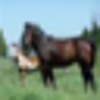

In [4]:
# 1 - 4行与上一块代码意义类似
(data, label) = trainset[12] # 选取训练集的一个样本展示内容，也可以改成其他数字看看
print(data.size())
print(label) # label是整数
print(classes[label])
show((data + 1) / 2).resize((100, 100)) # 还原被归一化的图片

# 2. 定义用于分类的网络结构

这一部分我们定义用于图像分类的网络结构，实现一个早期的卷积神经网络LeNet。它由两个卷积层和三个全连接层组成。pytorch为我们提供了方便的接口定义神经网络，但我们这里不着重介绍具体的语法，只观察数据是怎样在模型中“流动”的：
- 在`__init__`方法中，我们将上述的卷积层和全连接层初始化为`conv1、conv2`和`fc1、fc2、fc3`；
- 卷积层以`conv1`为例，它的初始化为`Conv2d(3, 6, 5)`，即：3输入通道（RGB图像的三个通道）、6输出通道、5*5大小的卷积核的卷积层。
- 全连接层以`fc1`为例，它的初始化为`Linear(16 * 5 * 5, 120)`，即：从400维映射到120维。
- `forward`方法用于规定数据在模型中的计算过程。输入的形状在传播过程中的变化参见`forward`中的注释。最终，我们得到了一个大小为`[batch size, 10]`的张量（矩阵）。

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        # nn.Module子类的函数必须在构造函数中执行父类的构造函数
        super(Net, self).__init__()

        # 卷积层 '3'表示输入图片为单通道, '6'表示输出通道数，'5'表示卷积核为5*5
        self.conv1 = nn.Conv2d(3, 6, 5)
        # 卷积层
        self.conv2 = nn.Conv2d(6, 16, 5) 
        # 仿射层/全连接层，y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120) 
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x): 
        # 卷积 -> 激活 -> 池化 (relu激活函数不改变输入的形状)
        # [batch size, 3, 32, 32] -- conv1 --> [batch size, 6, 28, 28] -- maxpool --> [batch size, 6, 14, 14]
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # [batch size, 6, 14, 14] -- conv2 --> [batch size, 16, 10, 10] --> maxpool --> [batch size, 16, 5, 5]
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        # 把 16 * 5 * 5 的特征图展平，变为 [batch size, 16 * 5 * 5]，以送入全连接层
        x = x.view(x.size()[0], -1) 
        # [batch size, 16 * 5 * 5] -- fc1 --> [batch size, 120]
        x = F.relu(self.fc1(x))
        # [batch size, 120] -- fc2 --> [batch size, 84]
        x = F.relu(self.fc2(x))
        # [batch size, 84] -- fc3 --> [batch size, 10]
        x = self.fc3(x)        
        return x

net = Net()
print(net)
# for p in net.parameters():
#     print(p)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [6]:
from torch import optim
criterion = nn.CrossEntropyLoss() # 交叉熵损失函数
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # 使用SGD（随机梯度下降）优化
num_epochs = 10 # 训练 10 个 epoch

下面我们定义用于训练过程的代码。最外层循环控制在整个数据集上训练的次数（即epoch）；内层循环按照以下流程进行：
1. 取出数据（一次取出一个batch）；
2. 将数据送入网络，计算损失函数；
3. 使用损失函数计算梯度，进行反向传播更新参数。

In [7]:
def train(trainloader, net, num_epochs, criterion, optimizer, save_path):
    for epoch in range(num_epochs):     
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
    
            # 1. 取出数据
            inputs, labels = data
    
            # 梯度清零
            optimizer.zero_grad()
    
            # 2. 前向计算和反向传播
            outputs = net(inputs) # 送入网络（正向传播）
            loss = criterion(outputs, labels) # 计算损失函数
            
            # 3. 反向传播，更新参数
            loss.backward() # 反向传播
            optimizer.step()

            # 下面的这段代码对于训练无实际作用，仅用于观察训练状态
            running_loss += loss.item()
            if i % 1000 == 999: # 每1000个batch打印一下训练状态
                print('epoch %d: batch %5d loss: %.3f' \
                      % (epoch+1, i+1, running_loss / 2000))
                running_loss = 0.0
                
        torch.save(net.state_dict(), f"{save_path}/epoch_{epoch + 1}_model.pth")
    print('Finished Training')

In [8]:
# 使用定义的网络进行训练
import os
os.makedirs('./results', exist_ok=True)
save_path = './results'
train(trainloader, net, num_epochs, criterion, optimizer, save_path)

epoch 1: batch  1000 loss: 1.148
epoch 1: batch  2000 loss: 1.077
epoch 1: batch  3000 loss: 0.995
epoch 1: batch  4000 loss: 0.915
epoch 1: batch  5000 loss: 0.842
epoch 1: batch  6000 loss: 0.833
epoch 1: batch  7000 loss: 0.811
epoch 1: batch  8000 loss: 0.793
epoch 1: batch  9000 loss: 0.760
epoch 1: batch 10000 loss: 0.762
epoch 1: batch 11000 loss: 0.754
epoch 1: batch 12000 loss: 0.753
epoch 2: batch  1000 loss: 0.702
epoch 2: batch  2000 loss: 0.699
epoch 2: batch  3000 loss: 0.690
epoch 2: batch  4000 loss: 0.701
epoch 2: batch  5000 loss: 0.672
epoch 2: batch  6000 loss: 0.671
epoch 2: batch  7000 loss: 0.663
epoch 2: batch  8000 loss: 0.667
epoch 2: batch  9000 loss: 0.657
epoch 2: batch 10000 loss: 0.654
epoch 2: batch 11000 loss: 0.659
epoch 2: batch 12000 loss: 0.643
epoch 3: batch  1000 loss: 0.615
epoch 3: batch  2000 loss: 0.613
epoch 3: batch  3000 loss: 0.612
epoch 3: batch  4000 loss: 0.600
epoch 3: batch  5000 loss: 0.601
epoch 3: batch  6000 loss: 0.592
epoch 3: b

训练过程结束后，我们得到了一个在训练集上拟合较好的模型。下面我们要测试它在测试集上表现如何。预测的代码与训练中的正向传播类似，但是不需要计算损失函数（损失函数在实验中仅用于更新参数，预测时参数固定，也就不需要它了）。

预测的流程如下：
1. 取出数据；
2. 正向传播，得到模型的输出结果；
3. 从输出结果中得到模型预测；
4. 和真实标签进行比对，计算性能指标。

注意：模型的输出结果在第2部分中已经说明，为一个`[batch size, 10]`大小的张量（矩阵），每一行是一条数据属于10个类别的概率的相对大小（这一输出也被称为`logits`）。为了得到模型的预测，我们需要对这一输出在每行上取最大值，取得最大值的**位置**就是模型的预测。

In [9]:
# 加载模型权重
net.load_state_dict(torch.load(save_path + '/epoch_5_model.pth'))

<All keys matched successfully>

In [10]:
def predict(testloader, net):
    correct = 0 # 预测正确的图片数
    total = 0  # 总共的图片数

    with torch.no_grad():  # 正向传播时不计算梯度
        for data in testloader:
            # 1. 取出数据
            images, labels = data
            # 2. 正向传播，得到输出结果
            outputs = net(images)
            # 3. 从输出中得到模型预测
            _, predicted = torch.max(outputs, 1)
            # 4. 计算性能指标
            total += labels.size(0)
            correct += (predicted == labels).sum()

    print('测试集中的准确率为: %d %%' % (100 * correct / total))

In [11]:
predict(testloader, net)

测试集中的准确率为: 60 %



# Task1：绘制损失函数曲线
损失函数能够量化模型在数据集上的拟合程度，帮助我们了解模型训练的进程。请在`3.模型训练与测试过程`中补充代码，记录训练过程中损失`loss`的变化，使用合适的Python数据类型将其保存，并使用`matplotlib`库将其可视化。可参照以下的代码进行绘图。你可以直接用损失函数可视化的代码覆盖下面的代码块。

In [12]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

def train_with_loss_plot(trainloader, net, num_epochs, criterion, optimizer, save_path):
    loss_values = []  # 用于保存每个 epoch 的平均损失值

    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            optimizer.zero_grad()             # 清除上一个 batch 的梯度
            outputs = net(inputs)             # 前向传播
            loss = criterion(outputs, labels) # 计算损失
            loss.backward()                   # 反向传播
            optimizer.step()                  # 更新参数
            running_loss += loss.item()       # 累加损失值

        # 记录每个 epoch 的平均损失值
        average_loss = running_loss / len(trainloader)
        loss_values.append(average_loss)
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {average_loss:.4f}')

    print('Finished Training')

    # 绘制损失变化曲线
    plt.plot(range(1, num_epochs + 1), loss_values, label="Training Loss")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()
    plt.show()
            
    return loss_values

请在报告中附上训练过程中损失函数的变化。训练集上的损失越小，说明模型的效果就越好吗？

# Task2: 加入正则化

- $L_2$正则化：请查阅Pytorch[有关SGD优化器的文档](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html#sgd)或其它网络资料，修改`3. 模型训练与测试过程`中的代码，尝试为模型的损失函数加入一项$L_2$损失，并在报告中说明你所做的修改。
- Dropout正则化：请查阅Pytorch[有关Dropout层的文档](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#dropout)或其它网络资料，修改`2. 定义用于分类的网络结构`中的代码，在**第一个线性层和第二个线性层之间**加入一个Dropout层，并在报告中说明你所做的修改。
- 在报告中简述两种正则化方法的基本原理。

In [13]:
# TODO: 在Dropout_Net中加入dropout层
class Dropout_Net(nn.Module):
    def __init__(self):
        super(Dropout_Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x): 
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size()[0], -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)        
        return x

class Dropout_Net(nn.Module):
    def __init__(self):
        # nn.Module子类的函数必须在构造函数中执行父类的构造函数
        super(Dropout_Net, self).__init__()

        # 卷积层 '1'表示输入图片为单通道, '6'表示输出通道数，'5'表示卷积核为5*5
        self.conv1 = nn.Conv2d(3, 6, 5) 
        # 卷积层
        self.conv2 = nn.Conv2d(6, 16, 5) 
        # 仿射层/全连接层，y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # 卷积 -> 激活 -> 池化
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        # reshape，‘-1’表示自适应
        x = x.view(x.size()[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
        dropout_net = Dropout_Net()

In [14]:
# TODO: 在这里重新定义optimizer，加入L2正则化项
dropout_net = Dropout_Net()
optimizer = optim.SGD(dropout_net.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
# 使用新定义的网络和优化器进行训练与测试
train(trainloader, dropout_net, num_epochs, criterion, optimizer, save_path)
predict(testloader, dropout_net)

epoch 1: batch  1000 loss: 1.150
epoch 1: batch  2000 loss: 1.117
epoch 1: batch  3000 loss: 1.035
epoch 1: batch  4000 loss: 1.002
epoch 1: batch  5000 loss: 0.963
epoch 1: batch  6000 loss: 0.916
epoch 1: batch  7000 loss: 0.888
epoch 1: batch  8000 loss: 0.860
epoch 1: batch  9000 loss: 0.839
epoch 1: batch 10000 loss: 0.830
epoch 1: batch 11000 loss: 0.814
epoch 1: batch 12000 loss: 0.795
epoch 2: batch  1000 loss: 0.781
epoch 2: batch  2000 loss: 0.790
epoch 2: batch  3000 loss: 0.764
epoch 2: batch  4000 loss: 0.763
epoch 2: batch  5000 loss: 0.767
epoch 2: batch  6000 loss: 0.756
epoch 2: batch  7000 loss: 0.734
epoch 2: batch  8000 loss: 0.729
epoch 2: batch  9000 loss: 0.730
epoch 2: batch 10000 loss: 0.735
epoch 2: batch 11000 loss: 0.726
epoch 2: batch 12000 loss: 0.724
epoch 3: batch  1000 loss: 0.695
epoch 3: batch  2000 loss: 0.719
epoch 3: batch  3000 loss: 0.706
epoch 3: batch  4000 loss: 0.708
epoch 3: batch  5000 loss: 0.706
epoch 3: batch  6000 loss: 0.684
epoch 3: b

# Task3: 调整参数
在`3. 模型训练与测试过程`部分中，我们定义了一些超参数（如`num_epoch`、优化器的`lr`）。调节这些参数，观察损失函数以及模型在测试集上的性能变化，在报告中简要说明这些指标的变化，尝试分析这些超参数对整个模型的影响。


Training with num_epochs=5, learning_rate=0.001
Epoch [1/5], Loss: 1.8068
Epoch [2/5], Loss: 1.5086
Epoch [3/5], Loss: 1.4179
Epoch [4/5], Loss: 1.3642
Epoch [5/5], Loss: 1.3284
Finished Training


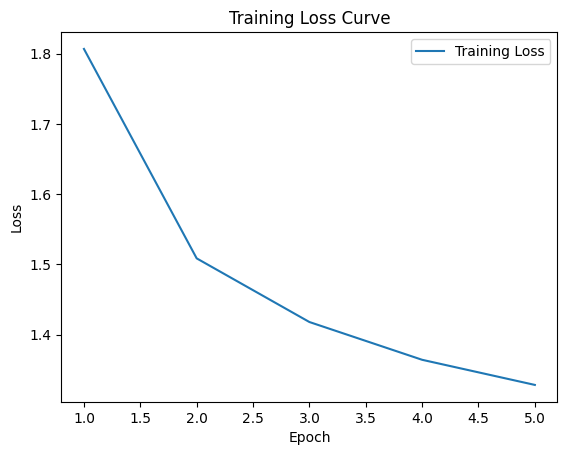

测试集中的准确率为: 54 %

Training with num_epochs=5, learning_rate=0.01
Epoch [1/5], Loss: 2.0242
Epoch [2/5], Loss: 1.9871
Epoch [3/5], Loss: 1.9827
Epoch [4/5], Loss: 1.9754
Epoch [5/5], Loss: 1.9779
Finished Training


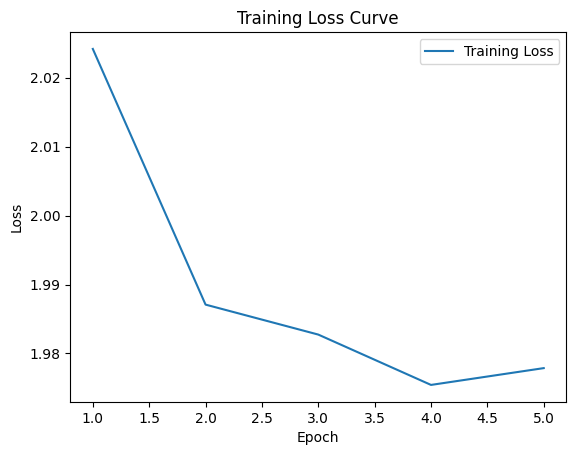

测试集中的准确率为: 25 %

Training with num_epochs=6, learning_rate=0.001
Epoch [1/6], Loss: 1.8164
Epoch [2/6], Loss: 1.5148
Epoch [3/6], Loss: 1.4172
Epoch [4/6], Loss: 1.3597
Epoch [5/6], Loss: 1.3218
Epoch [6/6], Loss: 1.2937
Finished Training


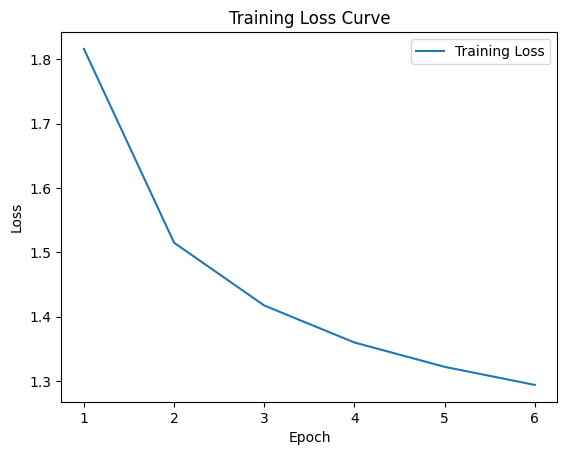

测试集中的准确率为: 55 %

Training with num_epochs=6, learning_rate=0.01
Epoch [1/6], Loss: 2.0085
Epoch [2/6], Loss: 1.9541
Epoch [3/6], Loss: 1.9505
Epoch [4/6], Loss: 1.9482
Epoch [5/6], Loss: 1.9600
Epoch [6/6], Loss: 1.9588
Finished Training


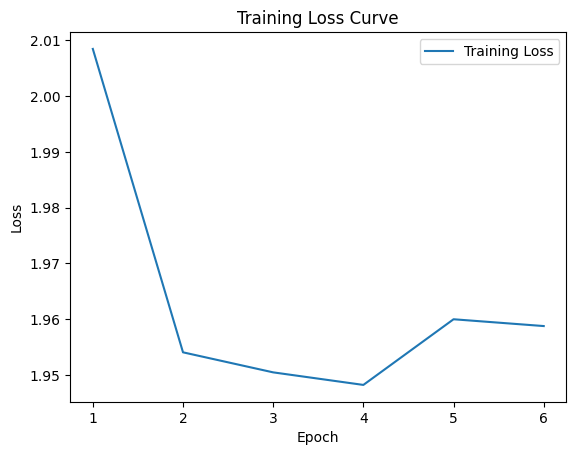

测试集中的准确率为: 27 %

Training with num_epochs=7, learning_rate=0.001
Epoch [1/7], Loss: 1.8221
Epoch [2/7], Loss: 1.4787
Epoch [3/7], Loss: 1.3886
Epoch [4/7], Loss: 1.3431
Epoch [5/7], Loss: 1.3071
Epoch [6/7], Loss: 1.2820
Epoch [7/7], Loss: 1.2637
Finished Training


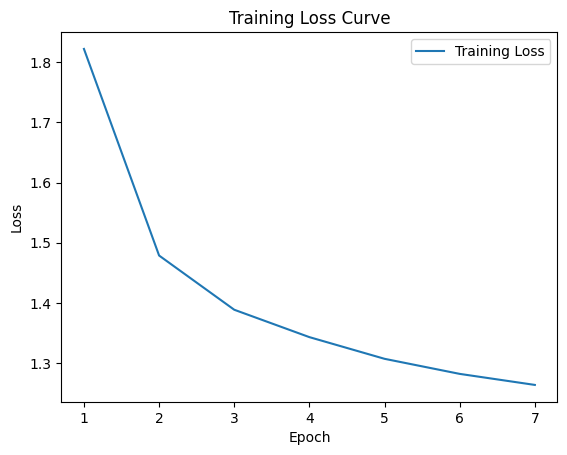

测试集中的准确率为: 54 %

Training with num_epochs=7, learning_rate=0.01
Epoch [1/7], Loss: 2.0468
Epoch [2/7], Loss: 1.9786
Epoch [3/7], Loss: 1.9772
Epoch [4/7], Loss: 1.9716
Epoch [5/7], Loss: 1.9671
Epoch [6/7], Loss: 1.9634
Epoch [7/7], Loss: 1.9733
Finished Training


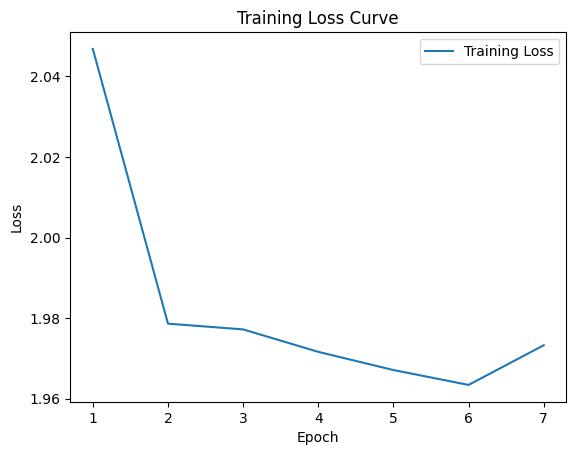

测试集中的准确率为: 27 %

Training with num_epochs=8, learning_rate=0.001
Epoch [1/8], Loss: 1.8495
Epoch [2/8], Loss: 1.5183
Epoch [3/8], Loss: 1.4247
Epoch [4/8], Loss: 1.3709
Epoch [5/8], Loss: 1.3298
Epoch [6/8], Loss: 1.3083
Epoch [7/8], Loss: 1.2884
Epoch [8/8], Loss: 1.2702
Finished Training


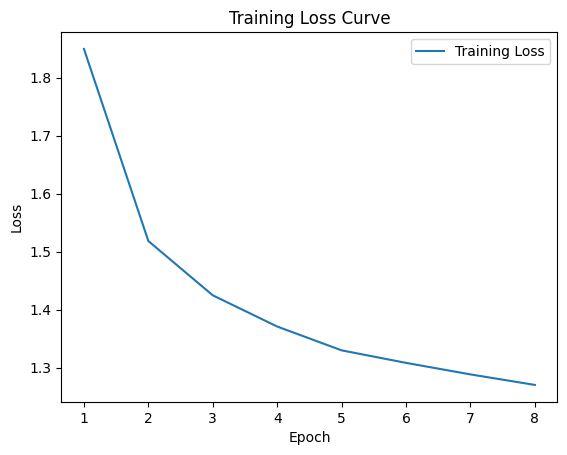

测试集中的准确率为: 52 %

Training with num_epochs=8, learning_rate=0.01
Epoch [1/8], Loss: 2.0300
Epoch [2/8], Loss: 1.9741
Epoch [3/8], Loss: 1.9812
Epoch [4/8], Loss: 1.9738
Epoch [5/8], Loss: 1.9645
Epoch [6/8], Loss: 1.9608
Epoch [7/8], Loss: 1.9768
Epoch [8/8], Loss: 1.9645
Finished Training


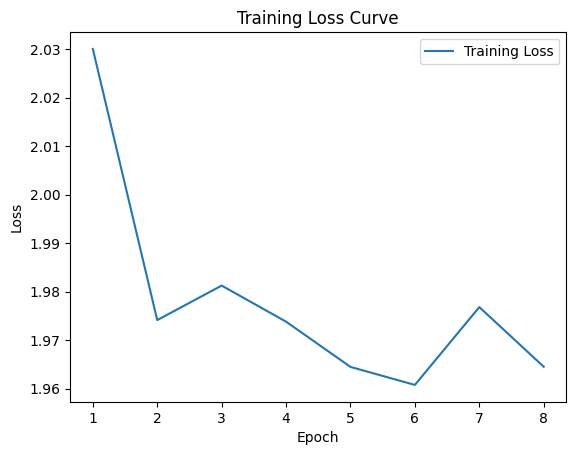

测试集中的准确率为: 25 %

Training with num_epochs=9, learning_rate=0.001
Epoch [1/9], Loss: 1.7764
Epoch [2/9], Loss: 1.4738
Epoch [3/9], Loss: 1.3918
Epoch [4/9], Loss: 1.3369
Epoch [5/9], Loss: 1.2968
Epoch [6/9], Loss: 1.2686
Epoch [7/9], Loss: 1.2487
Epoch [8/9], Loss: 1.2304
Epoch [9/9], Loss: 1.2187
Finished Training


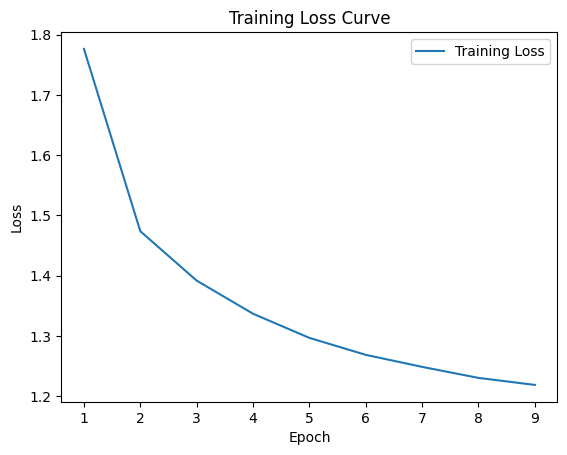

测试集中的准确率为: 58 %

Training with num_epochs=9, learning_rate=0.01
Epoch [1/9], Loss: 2.0268
Epoch [2/9], Loss: 1.9465
Epoch [3/9], Loss: 1.9406
Epoch [4/9], Loss: 1.9456
Epoch [5/9], Loss: 1.9611
Epoch [6/9], Loss: 1.9661
Epoch [7/9], Loss: 1.9705
Epoch [8/9], Loss: 1.9647
Epoch [9/9], Loss: 1.9648
Finished Training


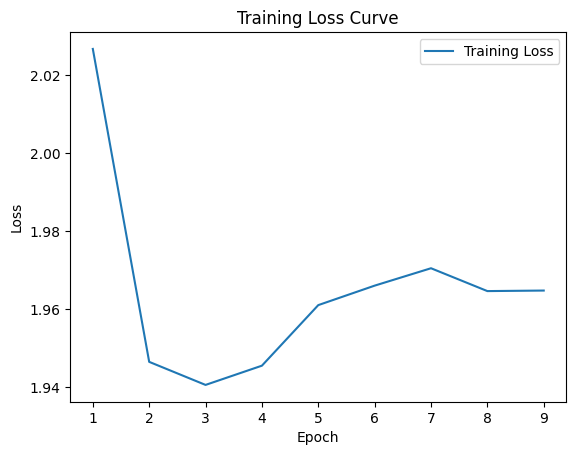

测试集中的准确率为: 25 %

Training with num_epochs=10, learning_rate=0.001
Epoch [1/10], Loss: 1.7975
Epoch [2/10], Loss: 1.4907
Epoch [3/10], Loss: 1.4176
Epoch [4/10], Loss: 1.3774
Epoch [5/10], Loss: 1.3461
Epoch [6/10], Loss: 1.3209
Epoch [7/10], Loss: 1.3005
Epoch [8/10], Loss: 1.2840
Epoch [9/10], Loss: 1.2618
Epoch [10/10], Loss: 1.2570
Finished Training


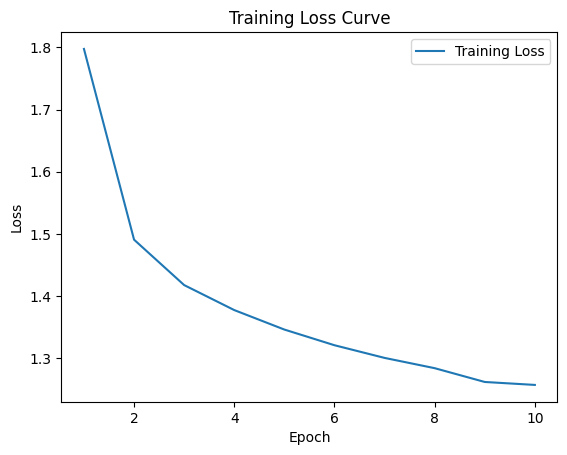

测试集中的准确率为: 57 %

Training with num_epochs=10, learning_rate=0.01
Epoch [1/10], Loss: 2.0281
Epoch [2/10], Loss: 1.9593
Epoch [3/10], Loss: 1.9653
Epoch [4/10], Loss: 1.9718
Epoch [5/10], Loss: 1.9664
Epoch [6/10], Loss: 1.9702
Epoch [7/10], Loss: 1.9563
Epoch [8/10], Loss: 1.9559
Epoch [9/10], Loss: 1.9696
Epoch [10/10], Loss: 1.9654
Finished Training


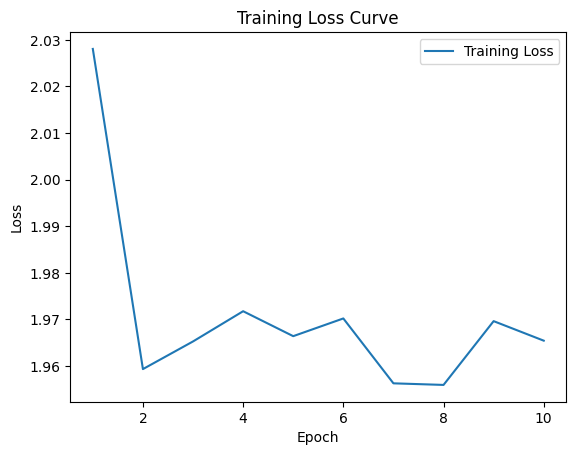

测试集中的准确率为: 30 %
    num_epochs  learning_rate  final_loss test_accuracy
0            5          0.001    1.328389          None
1            5          0.010    1.977875          None
2            6          0.001    1.293700          None
3            6          0.010    1.958765          None
4            7          0.001    1.263664          None
5            7          0.010    1.973263          None
6            8          0.001    1.270247          None
7            8          0.010    1.964501          None
8            9          0.001    1.218738          None
9            9          0.010    1.964820          None
10          10          0.001    1.257025          None
11          10          0.010    1.965432          None


In [15]:
# TODO: 在这里修改参数，重新进行训练和测试，并记录数据
import torch
import torch.optim as optim
import torch.nn as nn

# 调整超参数的设置
num_epochs_list = [5, 6, 7, 8, 9, 10]            # 设置不同的 epoch 数
learning_rate_list = [0.001, 0.01]   # 设置不同的学习率

# 定义数据记录变量
results = []

# 遍历每种超参数组合
for num_epochs in num_epochs_list:
    for lr in learning_rate_list:
        print(f"\nTraining with num_epochs={num_epochs}, learning_rate={lr}")

        # 实例化网络
        net = Dropout_Net()  # 假设已定义带 Dropout 的网络结构

        # 定义损失函数和优化器
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9, weight_decay=0.01)

        # 使用定义的训练函数，记录损失值
        loss_values = train_with_loss_plot(trainloader, net, num_epochs, criterion, optimizer, save_path='./results')

        # 在测试集上评估模型性能
        accuracy = predict(testloader, net)

        # 将结果存入列表中以便记录和比较
        results.append({
            "num_epochs": num_epochs,
            "learning_rate": lr,
            "final_loss": loss_values[-1],
            "test_accuracy": accuracy
        })

# 输出记录的结果以供分析
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)


# Task4: 实现自己的网络
查阅资料（参考：[动手学深度学习](https://zh.d2l.ai/chapter_convolutional-modern/index.html)以及[`torchvision`的模型源码](https://github.com/pytorch/vision/tree/main/torchvision/models)），修改`2. 定义用于分类的网络结构`中的代码，实现一种现代卷积神经网络。与最基础的LeNet相比，你实现的神经网络在性能、训练时间上有何差异？

In [ ]:
# TODO: 参考2.中Net的实现，设计自己的网络，进行训练和测试，并记录数据